In [1]:
# Project root setup
import os
import sys
from pathlib import Path

ROOT = next((path for path in (Path.cwd(), *Path.cwd().parents) if (path / "src").is_dir()), None)
if ROOT is None:
    raise RuntimeError("Could not locate the project root containing src/.")
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# Number of samples - Nonnegative CoLiDE

Replica of `synthetic/notebooks/number_samples.ipynb` for the nonnegative version of CoLiDE
(SCA+Adam, NV and EV) against NOMAD, DAGMA and CoLiDE (EV and NV), under three noise scenarios:
`var=1`, `var=10` and heteroscedastic (sigma_j ~ U(0.5, 5)).

The notebook imports `experiments/scripts/number_samples.py`, which holds all the experiment code
(methods, hyperparameters, metrics and saving), so the script and the notebook cannot diverge.

- `LOAD = True` (default): loads the results saved in `results/samples/` and plots them.
- `LOAD = False`: runs the experiment from the notebook (hours). To run it in the background use instead:

```
nohup .venv-dag/bin/python experiments/scripts/number_samples.py > logs/salida_nonneg_colide_samples.txt 2>&1 &
```

Metrics: SHD (mean +- std), normalized Frobenius error of W (median and 25-75 percentiles) and, for the methods
that estimate Sigma, the Sigma error computed after normalizing both vectors (same criterion as the error of W).

In [2]:
import importlib.util

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import src.utils as utils

# Import the experiment script as a module (methods, metrics, saving and plotting live there)
spec = importlib.util.spec_from_file_location("ns", ROOT / "experiments" / "scripts" / "number_samples.py")
ns = importlib.util.module_from_spec(spec)
spec.loader.exec_module(ns)

LOAD = True            # True: load saved results; False: run the experiment from the notebook
SAVE_FIGS = False      # save the figures next to the results
RESULTS_DIR = None     # None -> results/samples/ ; e.g. "results/samples_smoke/"

ns.LOAD = LOAD
ns.SAVE = not LOAD
if RESULTS_DIR is not None:
    ns.PATH = str(ROOT / RESULTS_DIR) + os.sep
os.makedirs(ns.PATH, exist_ok=True)
print("Results folder:", ns.PATH)

Results folder: /home/srey/Investigacion/nonneg_dag_learning/nomad/results/nonneg_colide/samples/


## Configuration

In [3]:
n_dags = 100
n_samples_values = np.array([50, 60, 80, 100, 200, 500, 1000, 5000, 10000])
thr = .2
verb = True

Exps = ns.build_experiments()
scenarios = {sc["name"]: sc for sc in ns.build_scenarios(n_nodes=100)}

pd.DataFrame([{"leg": e["leg"], "model": e["model"].__name__, "sigma": e["sigma"], "adapt_lamb": e["adapt_lamb"],
               **e.get("init", {}), **e["args"]} for e in Exps]).set_index("leg")

,model,sigma,adapt_lamb,primal_opt,acyclicity,equal_var,stepsize,step_type,alpha_0,rho_0,...,max_iter,T,warm_iter,lr,lambda2,num_iter,learning_rate,w_threshold,postprocess,checkpoint
leg,,,,,,,,,,,,,,,,,,,,,
NN-CoLiDE-NV,MetMulColide,True,True,sca,logdet,False,0.0003,fixed,0.01,0.05,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NN-CoLiDE-EV,MetMulColide,True,True,sca,logdet,True,0.0003,fixed,0.01,0.05,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NOMAD-adam,MetMulDagma,False,True,adam,logdet,NaN,0.0050,fixed,0.10,0.10,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NoTears,notears_linear,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DAGMA,DAGMA_linear,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,70000.0,4.0,20000.0,0.0003,NaN,NaN,NaN,NaN,NaN,NaN
CoLiDE-EV,colide_ev,True,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,70000.0,4.0,20000.0,0.0003,NaN,NaN,NaN,NaN,NaN,NaN
CoLiDE-NV,colide_nv,True,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,70000.0,4.0,20000.0,0.0003,NaN,NaN,NaN,NaN,NaN,NaN
GOLEM-EV,GOLEM_TF_EV,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,5.0,100000.0,0.001,0.3,True,NaN
GOLEM-NV,GOLEM_TF_NV,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,5.0,100000.0,0.001,0.3,True,NaN


## Plotting helpers

In [4]:
results = {}


def run_or_load(name, skip=()):
    sc = scenarios[name]
    out = ns.run_or_load_samples_results(sc["data_params"], n_samples_values, Exps, n_dags, sc["name"], thr=thr, verb=verb)
    *metrics, exps_out, xvals = out
    results[name] = {"metrics": dict(zip(ns.METRIC_NAMES, metrics)), "exps": exps_out, "xvals": xvals, "scenario": sc}
    return results[name]


def show_scenario(name, skip=()):
    res = run_or_load(name)
    m, exps_out, xvals, sc = res["metrics"], res["exps"], res["xvals"], res["scenario"]
    skip = list(skip)
    prefix = ns.samples_results_prefix(sc["name"])

    # SHD (mean +- std) and Fro error (median, prctiles 25-75)
    fig, _ = utils.plot_shd_error_pair(m["shd"], m["err"], exps_out, xvals, xlabel="Number of samples",
                                       shd_ylabel="SHD", err_ylabel="Fro Error", skip_idx=skip, alpha=.25,
                                       shd_agg="mean", shd_deviation="std", err_agg="median", err_deviation="prctile",
                                       err_plot_func="loglog", figsize=(10, 5), title=sc["title"])
    if SAVE_FIGS:
        fig.savefig(f"{prefix}_summary.png", bbox_inches="tight")

    # Sigma error (only methods that estimate Sigma)
    fig, _ = ns.plot_sigma_error(m["err_sig"], exps_out, xvals, skip_idx=skip, title=f'{sc["title"]} - Sigma error')
    if SAVE_FIGS:
        fig.savefig(f"{prefix}_sigma_error.png", bbox_inches="tight")

    # Tables at each number of samples
    legs = [e["leg"] for e in exps_out]
    for metric, agg, label in [("shd", np.mean, "SHD (mean)"), ("err", np.median, "Fro error (median)"),
                               ("err_sig", np.nanmedian, "Sigma error (median)"), ("runtime", np.mean, "time (mean, s)")]:
        with np.errstate(all="ignore"):
            table = pd.DataFrame(agg(m[metric], axis=0), index=xvals, columns=legs).rename_axis("samples")
        print(f"\n{sc['title']} - {label}")
        display(table.round(4))
    return res


def show_all_metrics(name, agg="mean", skip=()):
    m, exps_out, xvals = results[name]["metrics"], results[name]["exps"], results[name]["xvals"]
    utils.plot_all_metrics(m["shd"], m["tpr"], m["fdr"], m["fscore"], m["err"], m["acyc"], m["runtime"],
                           m["dag_count"], xvals, exps_out, skip_idx=list(skip), agg=agg)

## Scenario 1: variance 1

[2026-09-21T13:10:05 pid=215668] Loaded samples results from /home/srey/Investigacion/nonneg_dag_learning/nomad/results/nonneg_colide/samples/samples_er4_N100_var1.npz

var = 1 - SHD (mean)


,NN-CoLiDE-NV,NN-CoLiDE-EV,NOMAD-adam,NoTears,DAGMA,CoLiDE-EV,CoLiDE-NV,GOLEM-EV,GOLEM-NV
samples,,,,,,,,,
50,188.21,156.63,94.17,225.98,387.08,583.63,905.22,698.02,955.33
60,133.03,115.36,65.47,184.34,309.22,456.63,701.29,734.24,1047.99
80,74.36,65.37,33.02,129.06,183.73,261.95,332.79,703.83,1254.10
100,44.43,38.71,18.76,110.84,124.45,160.89,190.19,421.70,1027.58
200,7.91,6.53,2.24,68.50,40.48,43.11,51.95,33.22,125.83
500,1.15,0.35,0.07,53.45,27.60,28.69,34.79,7.67,9.86
1000,0.67,0.09,0.07,49.36,25.18,25.84,30.57,6.26,7.51
5000,0.67,0.05,0.05,44.24,25.48,26.12,29.52,7.24,8.34
10000,0.83,0.05,0.08,45.77,26.55,28.71,33.62,5.98,7.10



var = 1 - Fro error (median)


,NN-CoLiDE-NV,NN-CoLiDE-EV,NOMAD-adam,NoTears,DAGMA,CoLiDE-EV,CoLiDE-NV,GOLEM-EV,GOLEM-NV
samples,,,,,,,,,
50,0.2244,0.1986,0.1867,0.5512,0.5284,0.6492,0.8499,1.1440,1.2213
60,0.1586,0.1437,0.1332,0.4516,0.4290,0.5146,0.6720,1.1458,1.2105
80,0.1021,0.0928,0.0825,0.3193,0.2844,0.3394,0.3843,1.0528,1.1965
100,0.0749,0.0688,0.0603,0.2858,0.2209,0.2478,0.2783,0.6316,0.8886
200,0.0323,0.0292,0.0230,0.1791,0.1147,0.1163,0.1333,0.0812,0.1393
500,0.0114,0.0102,0.0078,0.1338,0.0701,0.0701,0.0825,0.0269,0.0300
1000,0.0051,0.0049,0.0037,0.1157,0.0622,0.0598,0.0674,0.0195,0.0216
5000,0.0010,0.0009,0.0007,0.1114,0.0579,0.0530,0.0598,0.0201,0.0218
10000,0.0005,0.0005,0.0003,0.1108,0.0566,0.0591,0.0666,0.0154,0.0165



var = 1 - Sigma error (median)


,NN-CoLiDE-NV,NN-CoLiDE-EV,NOMAD-adam,NoTears,DAGMA,CoLiDE-EV,CoLiDE-NV,GOLEM-EV,GOLEM-NV
samples,,,,,,,,,
50,0.0455,0.0,NaN,NaN,NaN,0.0,0.4351,NaN,NaN
60,0.0281,0.0,NaN,NaN,NaN,0.0,0.2307,NaN,NaN
80,0.0162,0.0,NaN,NaN,NaN,0.0,0.0644,NaN,NaN
100,0.0110,0.0,NaN,NaN,NaN,0.0,0.0338,NaN,NaN
200,0.0041,0.0,NaN,NaN,NaN,0.0,0.0135,NaN,NaN
500,0.0013,0.0,NaN,NaN,NaN,0.0,0.0100,NaN,NaN
1000,0.0006,0.0,NaN,NaN,NaN,0.0,0.0085,NaN,NaN
5000,0.0001,0.0,NaN,NaN,NaN,0.0,0.0084,NaN,NaN
10000,0.0001,0.0,NaN,NaN,NaN,0.0,0.0095,NaN,NaN



var = 1 - time (mean, s)


,NN-CoLiDE-NV,NN-CoLiDE-EV,NOMAD-adam,NoTears,DAGMA,CoLiDE-EV,CoLiDE-NV,GOLEM-EV,GOLEM-NV
samples,,,,,,,,,
50,61.9798,71.3531,47.3641,5142.1326,84.4535,133.1434,284.0077,1530.2338,2847.9341
60,81.9417,95.2216,58.3460,4737.8973,82.2682,125.9512,261.9589,1672.1554,3487.5396
80,65.0147,82.2334,49.1301,4065.2284,92.1197,130.1314,141.9049,1871.6029,3614.1885
100,65.6097,79.2431,50.9314,3356.0463,83.7584,110.0541,120.3854,2033.1407,3680.7931
200,54.2231,70.6963,45.0523,2522.7697,67.6044,87.1663,93.5129,1890.8110,4134.0128
500,55.9565,75.3763,48.1666,2502.4422,72.2915,94.0434,99.4139,2412.0175,5092.0716
1000,57.5064,71.1508,50.3378,2953.1588,68.3635,86.2504,92.5381,3316.4441,6981.7476
5000,57.5350,75.0064,53.6582,10669.8110,77.9212,97.2839,102.8122,7414.1753,16312.3986
10000,88.5108,115.1061,85.4563,20899.0668,119.1571,148.3390,158.5268,11150.3745,18983.0904


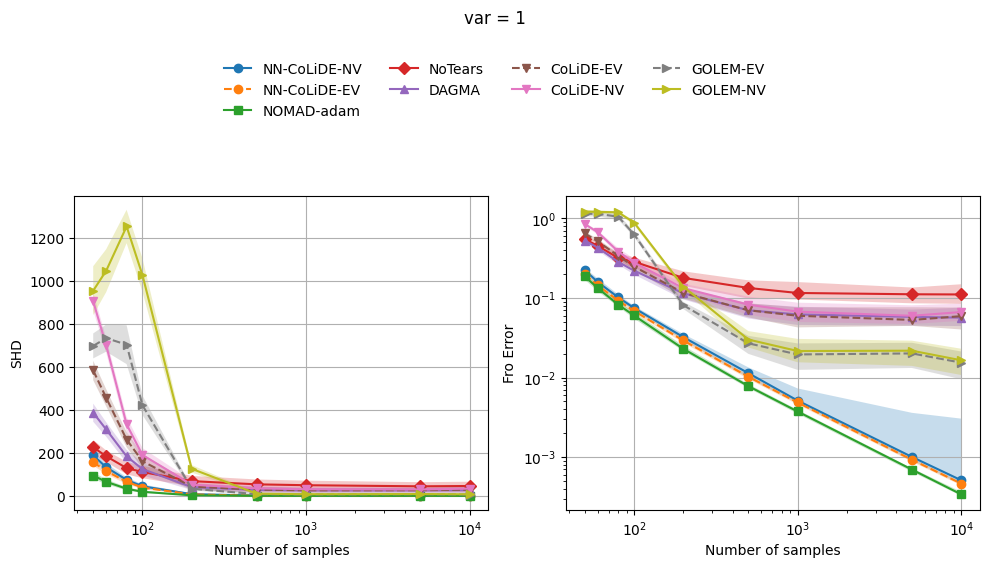

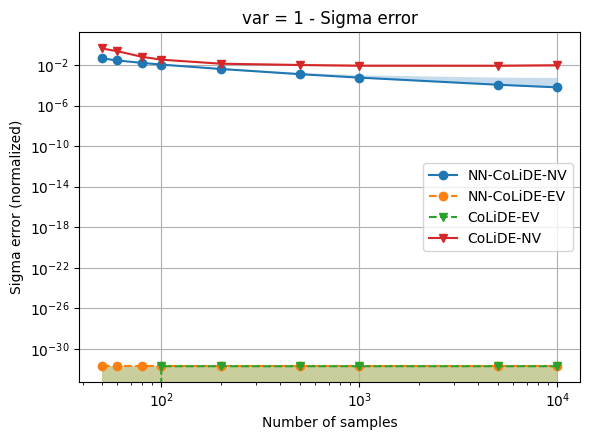

In [5]:
skip = []
res = show_scenario("er4_N100_var1", skip=skip)

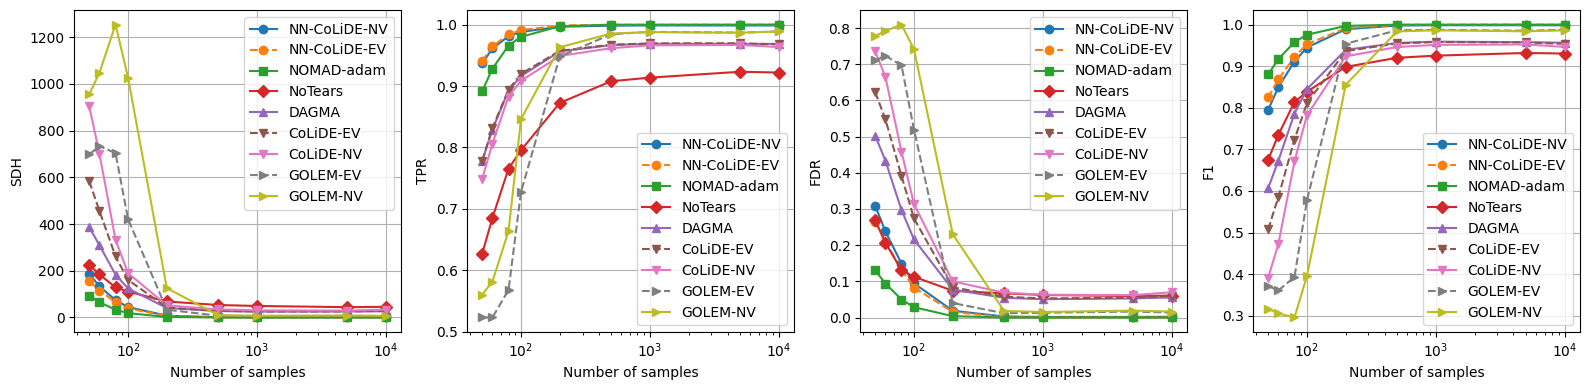

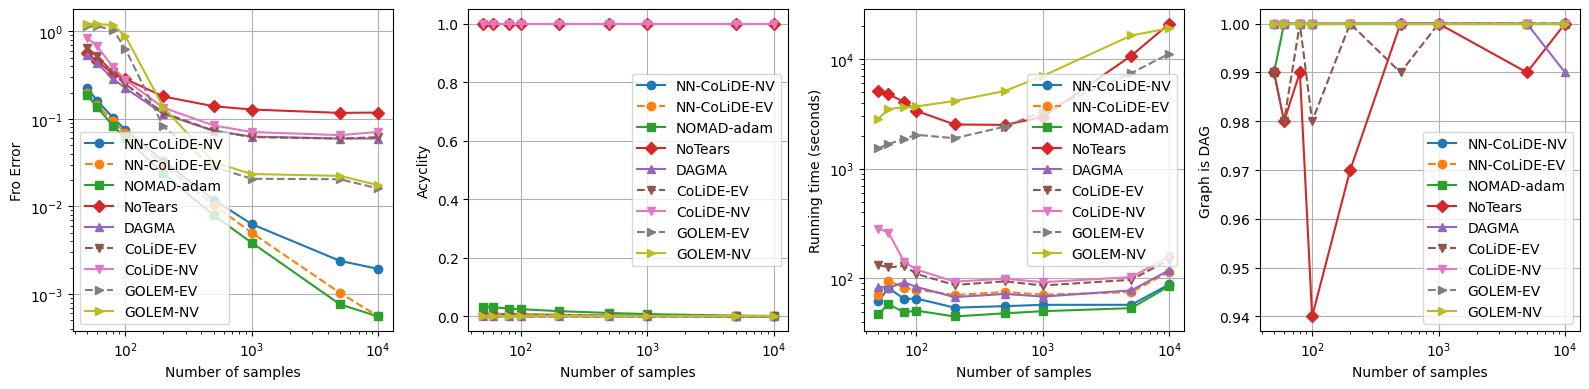

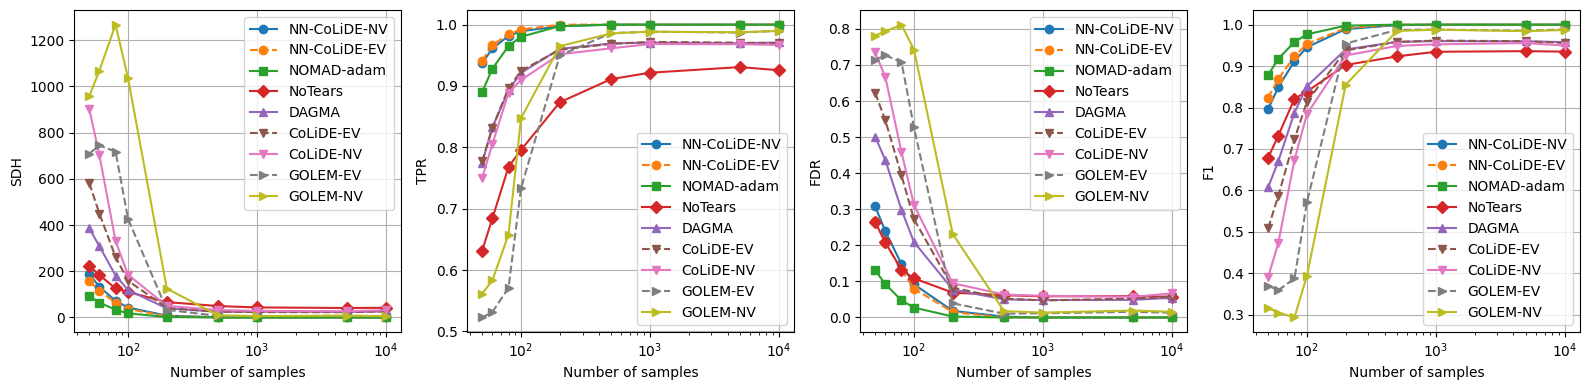

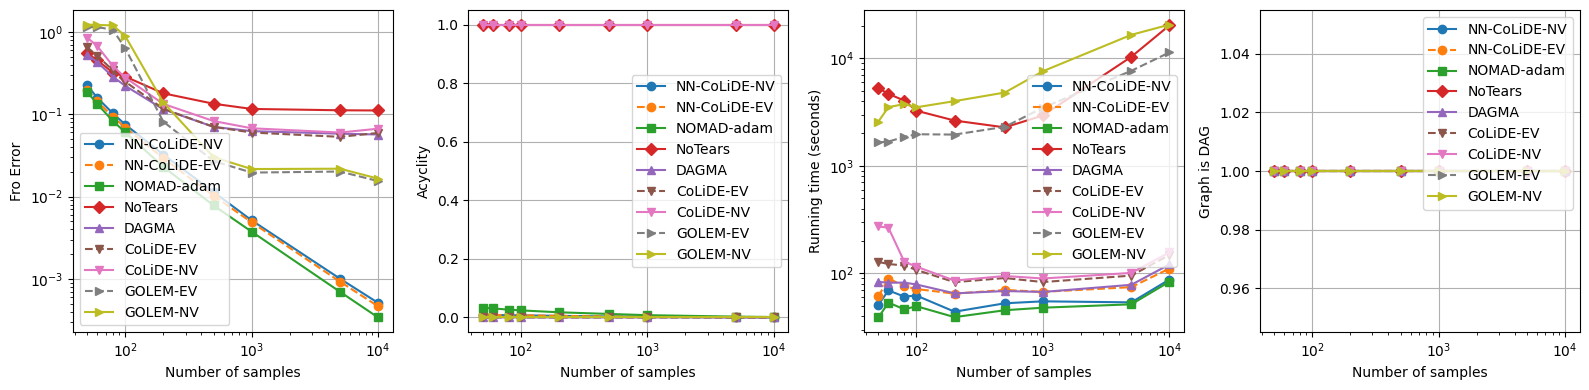

In [6]:
show_all_metrics("er4_N100_var1", agg="mean", skip=skip)
show_all_metrics("er4_N100_var1", agg="median", skip=skip)

## Scenario 2: variance 10

In [7]:
skip = []
res = show_scenario("er4_N100_var10", skip=skip)

KeyError: 'er4_N100_var10'

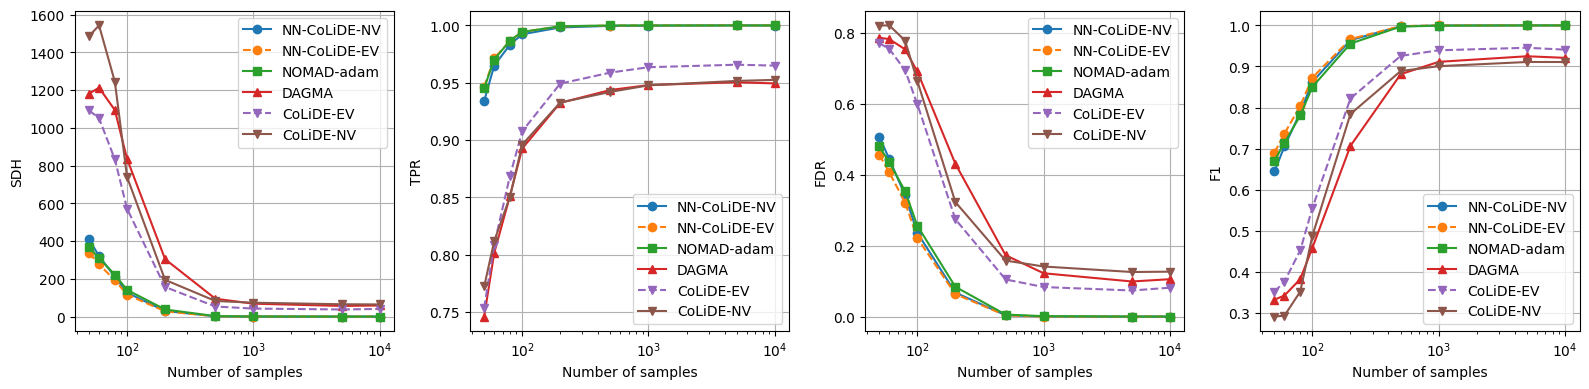

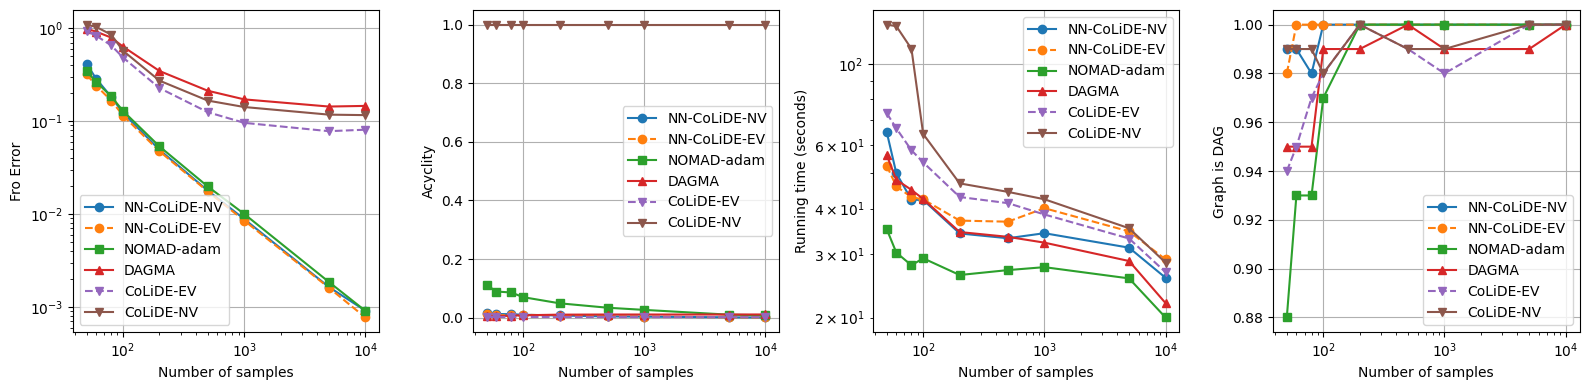

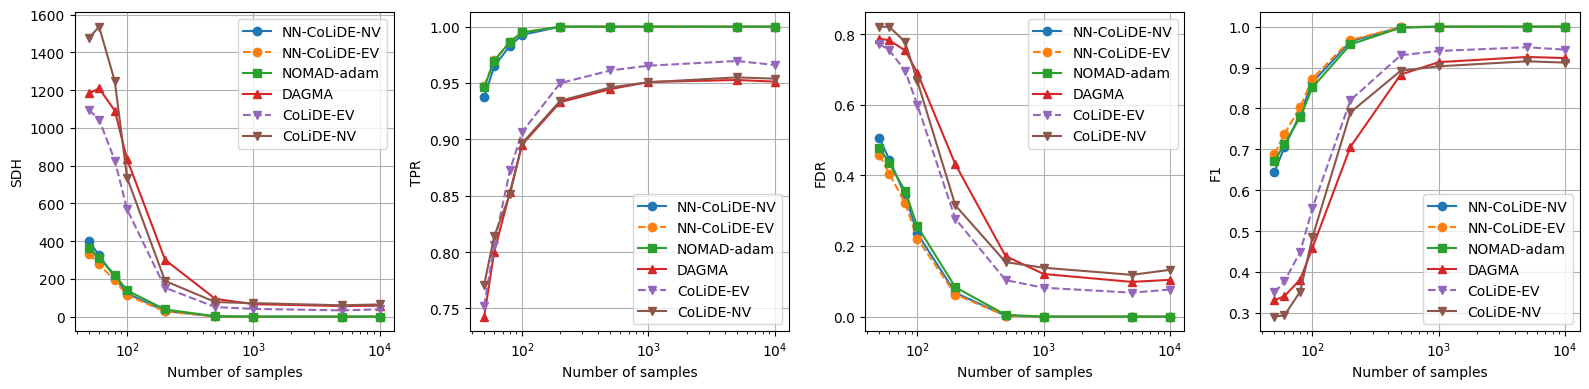

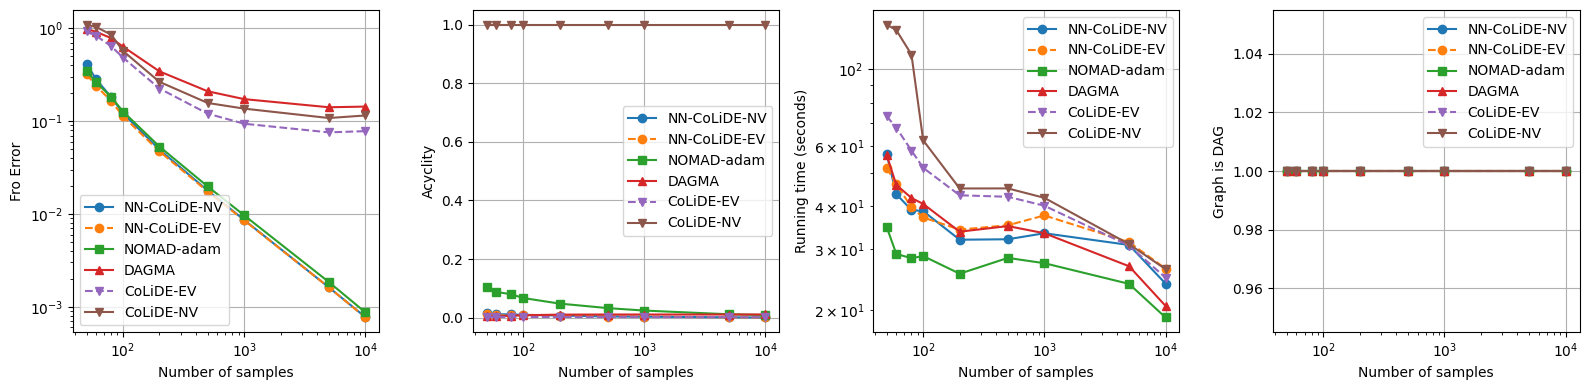

In [ ]:
show_all_metrics("er4_N100_var10", agg="mean", skip=skip)
show_all_metrics("er4_N100_var10", agg="median", skip=skip)

## Scenario 3: heteroscedastic, sigma_j ~ U(0.5, 5)

[2026-09-14T18:19:01 pid=18563] Loaded samples results from /home/srey/Investigacion/nonneg_dag_learning/nomad/results/nonneg_colide/samples/samples_er4_N100_hetero.npz

heteroscedastic - SHD (mean)


,NN-CoLiDE-NV,NN-CoLiDE-EV,NOMAD-adam,DAGMA,CoLiDE-EV,CoLiDE-NV
samples,,,,,,
50,400.18,352.90,374.81,1304.49,1263.12,1510.04
60,327.92,307.89,330.72,1382.49,1258.06,1527.65
80,243.74,242.59,266.77,1347.92,1090.02,1151.55
100,173.90,179.75,201.57,1181.63,881.07,809.30
200,81.56,95.09,110.22,734.99,512.19,432.96
500,28.22,40.04,46.36,455.20,351.47,317.48
1000,15.18,25.44,29.66,388.90,322.81,297.13
5000,10.95,20.52,21.33,355.26,308.65,282.37
10000,10.26,18.61,19.33,355.52,311.71,286.39



heteroscedastic - Fro error (median)


,NN-CoLiDE-NV,NN-CoLiDE-EV,NOMAD-adam,DAGMA,CoLiDE-EV,CoLiDE-NV
samples,,,,,,
50,0.5191,0.4894,0.5100,1.2530,1.2656,1.3016
60,0.4132,0.4180,0.4358,1.2534,1.2220,1.2680
80,0.3003,0.3214,0.3400,1.2086,1.1110,1.1078
100,0.2190,0.2452,0.2611,1.1195,0.9890,0.9074
200,0.1209,0.1445,0.1579,0.9199,0.8144,0.7534
500,0.0712,0.0863,0.0934,0.8134,0.7334,0.6917
1000,0.0519,0.0707,0.0767,0.7783,0.7019,0.6738
5000,0.0410,0.0618,0.0675,0.7514,0.6828,0.6391
10000,0.0426,0.0620,0.0642,0.7563,0.6943,0.6610



heteroscedastic - Sigma error (median)


/usr/local/lib/python3.8/dist-packages/numpy/lib/nanfunctions.py:1217: RuntimeWarning: All-NaN slice encountered
  r, k = function_base._ureduce(a, func=_nanmedian, axis=axis, out=out,


,NN-CoLiDE-NV,NN-CoLiDE-EV,NOMAD-adam,DAGMA,CoLiDE-EV,CoLiDE-NV
samples,,,,,,
50,0.0879,0.1743,NaN,NaN,0.1743,0.7208
60,0.0607,0.1743,NaN,NaN,0.1743,0.5595
80,0.0421,0.1743,NaN,NaN,0.1743,0.3035
100,0.0397,0.1743,NaN,NaN,0.1743,0.2207
200,0.0252,0.1743,NaN,NaN,0.1743,0.1844
500,0.0219,0.1743,NaN,NaN,0.1743,0.1778
1000,0.0228,0.1743,NaN,NaN,0.1743,0.1830
5000,0.0236,0.1743,NaN,NaN,0.1743,0.1785
10000,0.0274,0.1743,NaN,NaN,0.1743,0.1832



heteroscedastic - time (mean, s)


,NN-CoLiDE-NV,NN-CoLiDE-EV,NOMAD-adam,DAGMA,CoLiDE-EV,CoLiDE-NV
samples,,,,,,
50,74.1800,61.9401,33.6404,60.2171,85.4456,129.5671
60,60.2992,57.4750,30.7038,60.0654,78.8108,128.6191
80,56.2180,55.3850,29.3509,50.9884,62.5532,92.9533
100,52.0824,50.8974,29.3727,49.5731,59.2048,67.0067
200,45.3511,46.4082,29.9942,41.1350,51.3249,55.7652
500,51.5142,52.3293,32.6037,40.2590,51.6884,58.1070
1000,51.1956,51.4062,31.1486,37.3669,47.0552,50.3690
5000,47.9868,49.8483,29.1919,33.2990,40.4967,41.7369
10000,37.8770,38.3156,24.1779,27.1460,32.6459,33.2473


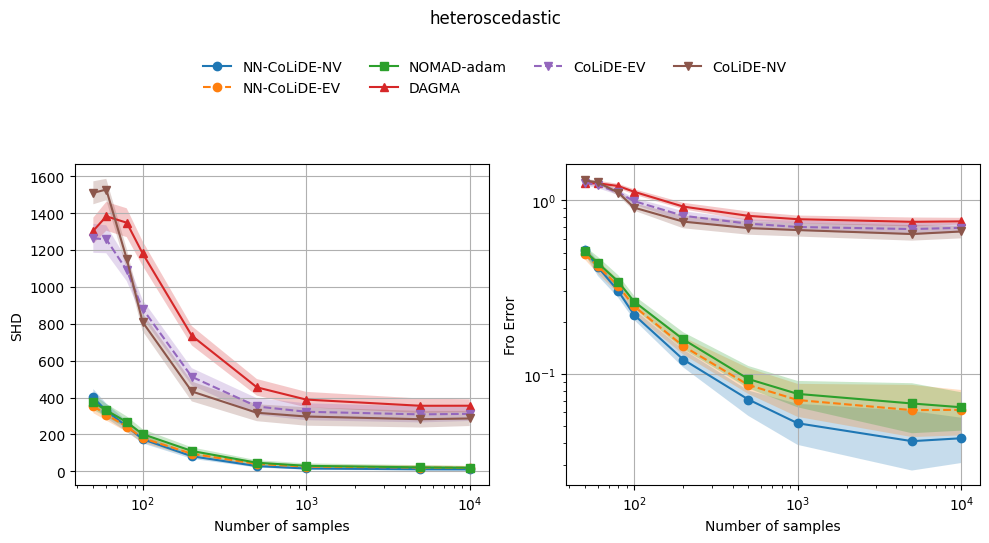

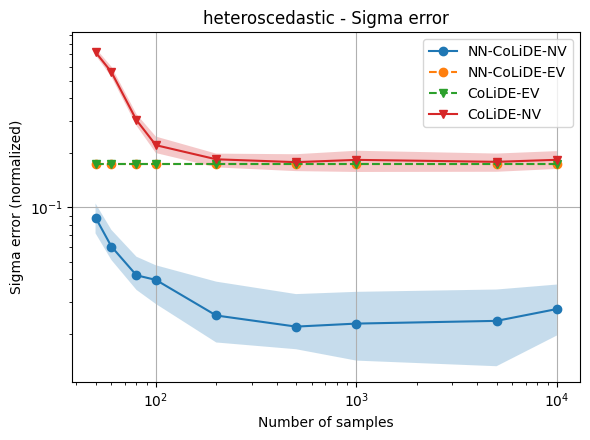

In [ ]:
skip = []
res = show_scenario("er4_N100_hetero", skip=skip)

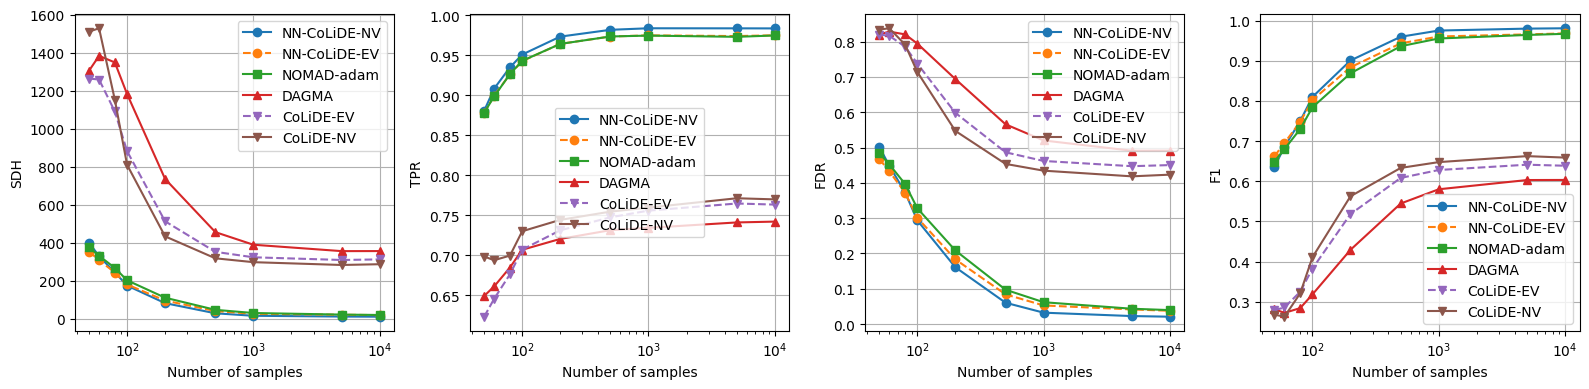

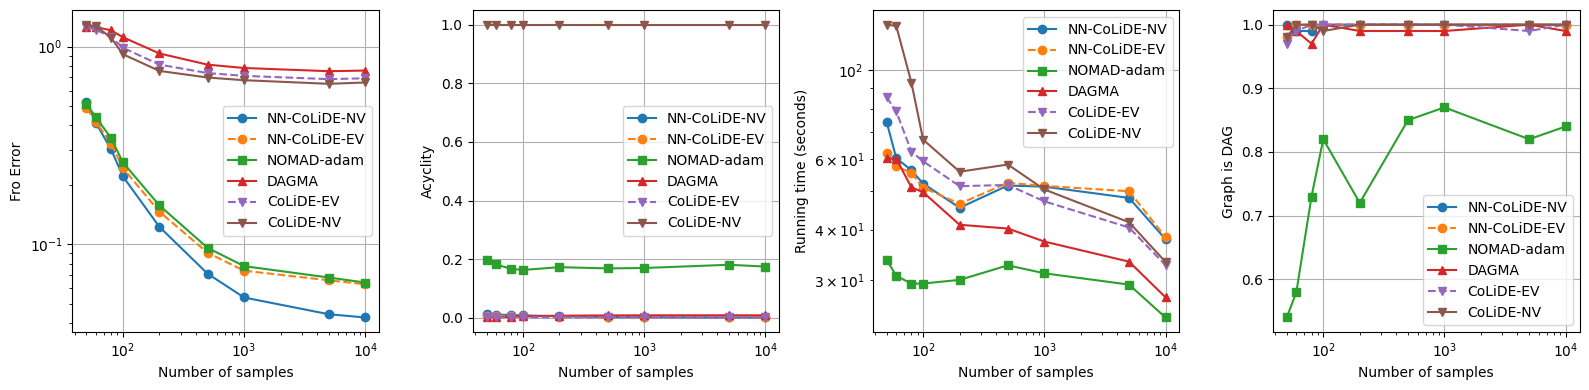

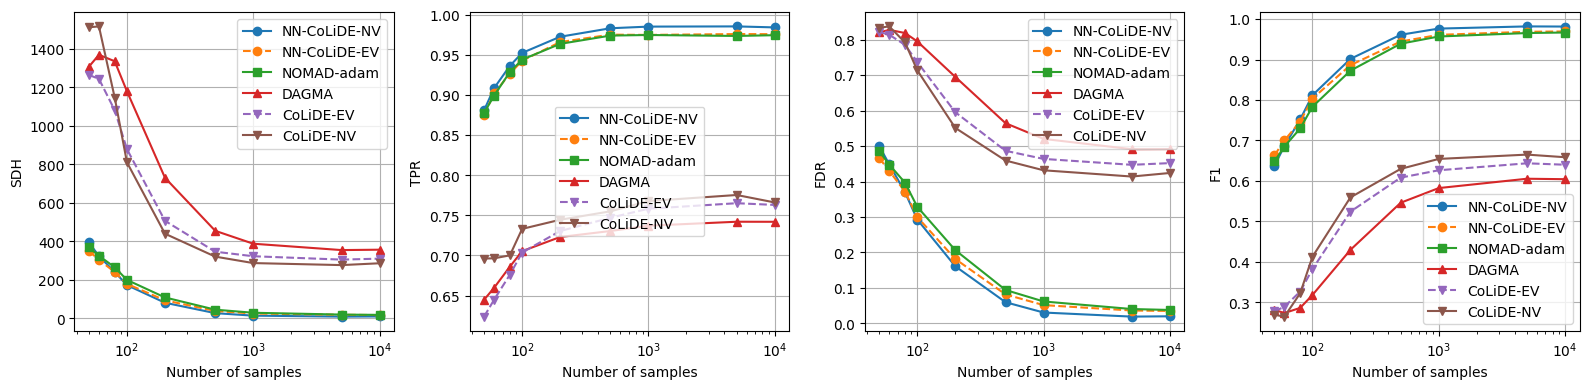

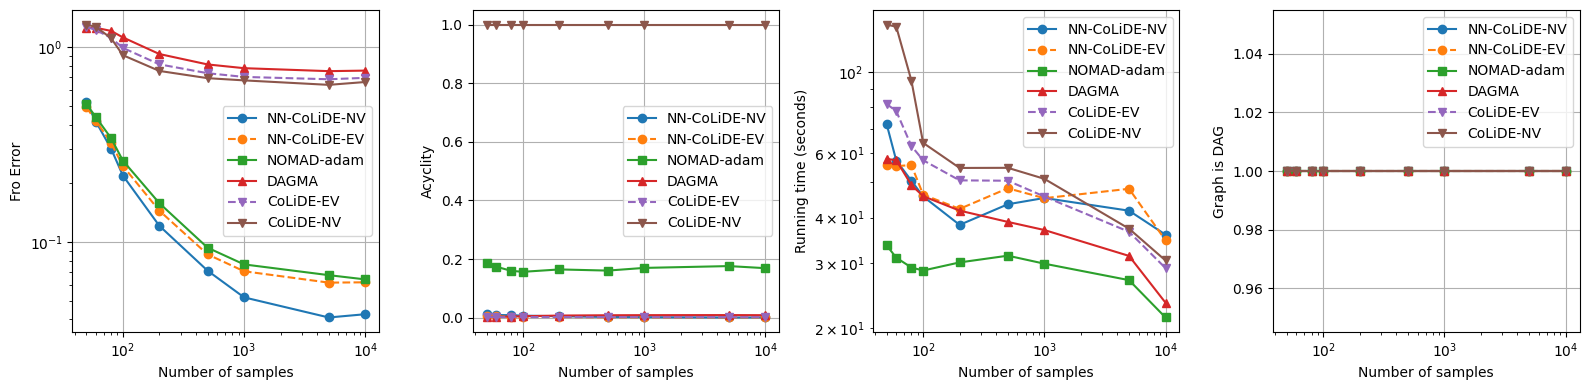

In [ ]:
show_all_metrics("er4_N100_hetero", agg="mean", skip=skip)
show_all_metrics("er4_N100_hetero", agg="median", skip=skip)

## Joint comparison of the three scenarios

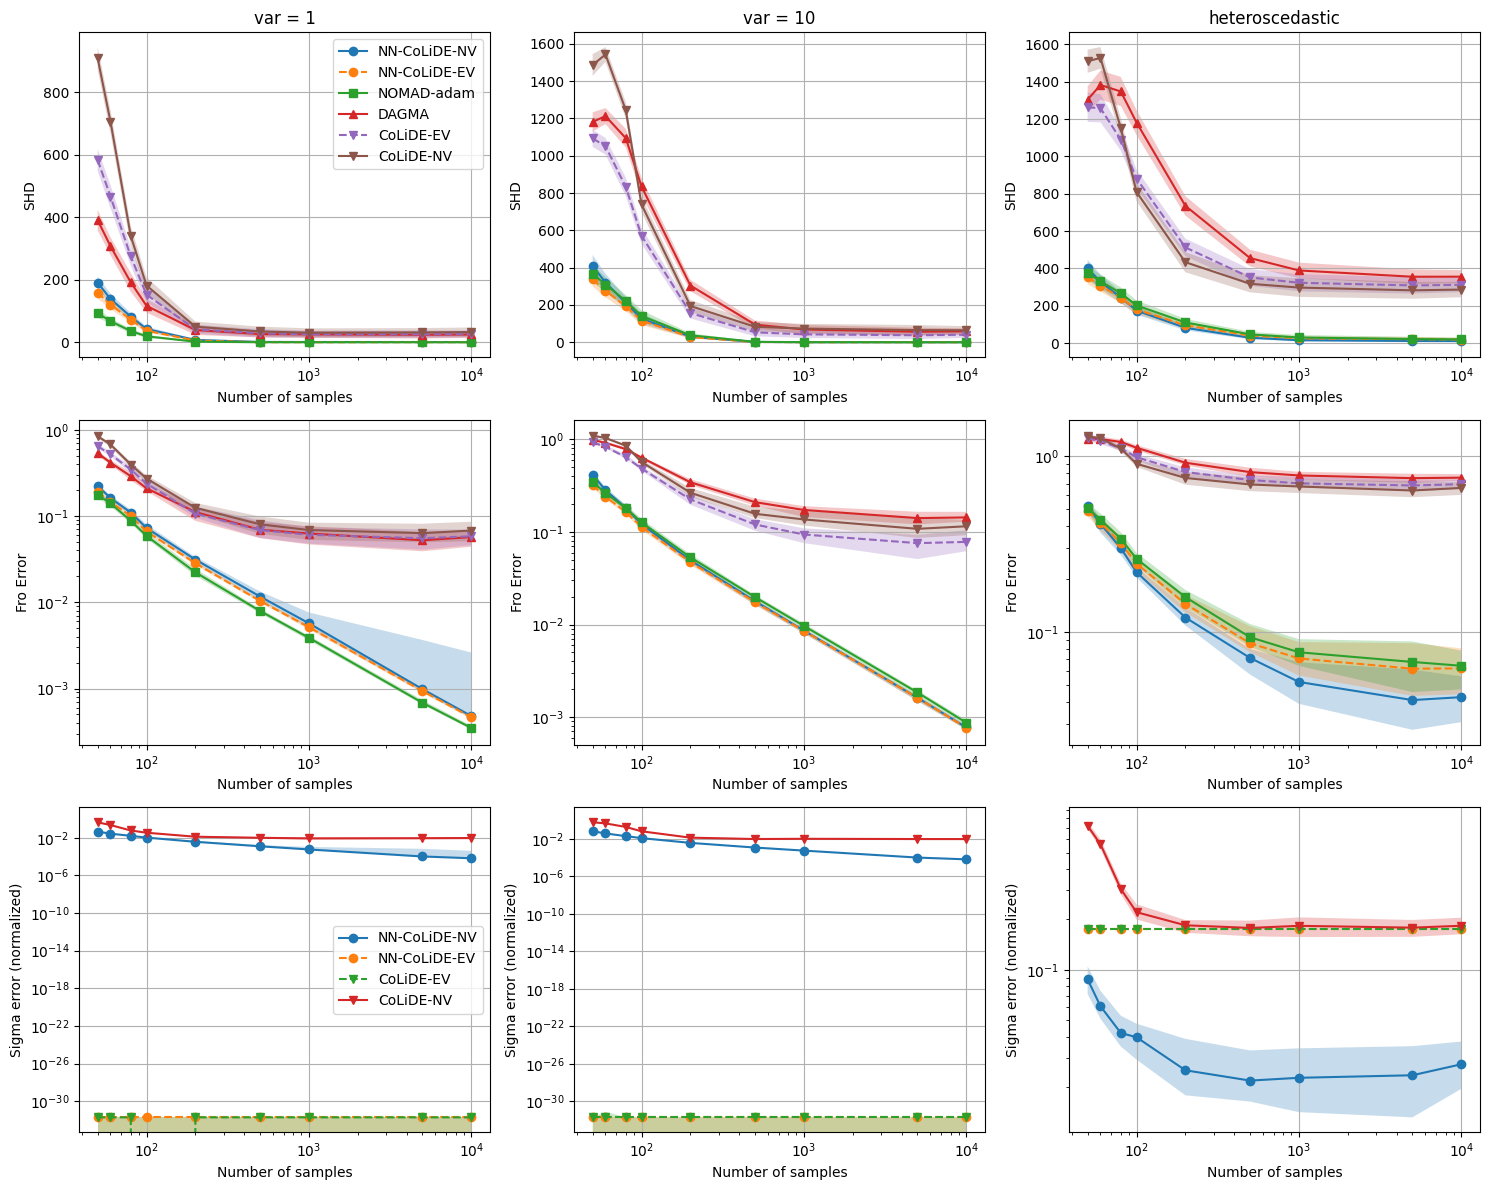

In [ ]:
names = [n for n in scenarios if n in results]
skip = []
fig, axes = plt.subplots(3, len(names), figsize=(5 * len(names), 12), squeeze=False)
for c, name in enumerate(names):
    m, exps_out, xvals, sc = results[name]["metrics"], results[name]["exps"], results[name]["xvals"], results[name]["scenario"]
    utils.plot_data(axes[0, c], m["shd"], exps_out, xvals, "Number of samples", "SHD", skip,
                    agg="mean", deviation="std", alpha=.25, legend=(c == 0))
    utils.plot_data(axes[1, c], m["err"], exps_out, xvals, "Number of samples", "Fro Error", skip,
                    agg="median", deviation="prctile", alpha=.25, plot_func="loglog", legend=False)
    utils.plot_data(axes[2, c], m["err_sig"], exps_out, xvals, "Number of samples", "Sigma error (normalized)",
                    ns.sigma_skip_idx(exps_out, skip), agg="median", deviation="prctile", alpha=.25,
                    plot_func="loglog", legend=(c == 0))
    axes[0, c].set_title(sc["title"])
plt.tight_layout()
if SAVE_FIGS:
    fig.savefig(f"{ns.PATH}samples_joint_scenarios.png", bbox_inches="tight")